In [ ]:
# 한국교육개발원 데이터 로드
df_edu = pd.read_csv('input/한국교육개발원_고등교육기관 졸업자 학과별 졸업 후 상황_20260121.csv', encoding='euc-kr')

print(f'데이터 크기: {df_edu.shape}')
print(f'행 수: {len(df_edu)}, 컬럼 수: {df_edu.shape[1]}')
print()
print('컬럼명:')
print(df_edu.columns.tolist())
print()
print('데이터 첫 3행:')
print(df_edu.head(3))
print()
print('결측치 확인:')
print(df_edu.isnull().sum().sum())

## 1단계: 데이터 로드 및 기본 확인

---
## 🆕 한국교육개발원 데이터 - RandomForest 분류 모델

In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report
import seaborn as sns

# 한글 폰트 설정 (Windows)
import platform
from matplotlib import rc
if platform.system() == 'Windows':
    plt.rc('font', family='Malgun Gothic')

# 출력 형식 설정
np.set_printoptions(suppress=True, precision=4)
pd.options.display.float_format = '{:,.4f}'.format
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)
plt.rcParams['font.size'] = 14

random_seed = 123

## 1단계: 데이터 로드 및 확인

In [2]:
# 데이터 로드
df = pd.read_csv('input/경상북도문화관광공사_보문관광단지 내외국인 관광객 통계_20251231.csv', encoding='euc-kr')

# 기본 데이터 확인
print(f'데이터 크기: {df.shape}')
print(f'기간: {df.iloc[0, 0]} ~ {df.iloc[-1, 0]}')
print()
print('컬럼명:')
print(df.columns.tolist())
print()
print('결측치:')
print(df.isnull().sum())
print()
print('데이터 첫 5행:')
print(df.head())

데이터 크기: (36, 10)
기간: 2023-01-01 ~ 2025-12-01

컬럼명:
['기준연월일', '외국인관광객수', '중국국적관광객수', '대만국적관광객수', '홍콩국적관광객수', '일본국적관광객수', '미국국적관광객수', '유럽국적관광객수', '기타국적관광객수', '내국인관광객수']

결측치:
기준연월일       0
외국인관광객수     0
중국국적관광객수    0
대만국적관광객수    0
홍콩국적관광객수    0
일본국적관광객수    0
미국국적관광객수    0
유럽국적관광객수    0
기타국적관광객수    0
내국인관광객수     0
dtype: int64

데이터 첫 5행:
        기준연월일  외국인관광객수  중국국적관광객수  대만국적관광객수  홍콩국적관광객수  일본국적관광객수  미국국적관광객수  \
0  2023-01-01     2803        16       461         6        25       245   
1  2023-02-01     3825        89       246         0        24       235   
2  2023-03-01     5318        72      1242        20       109       608   
3  2023-04-01     8699       243       697        43       181      1573   
4  2023-05-01     7007       131      1027         8       173      1162   

   유럽국적관광객수  기타국적관광객수  내국인관광객수  
0        16      2034   390185  
1       123      3108   427775  
2       470      2797   386230  
3      1983      3979   446814  
4      1215      3291   502981  


## 2단계: 탐색적 데이터 분석

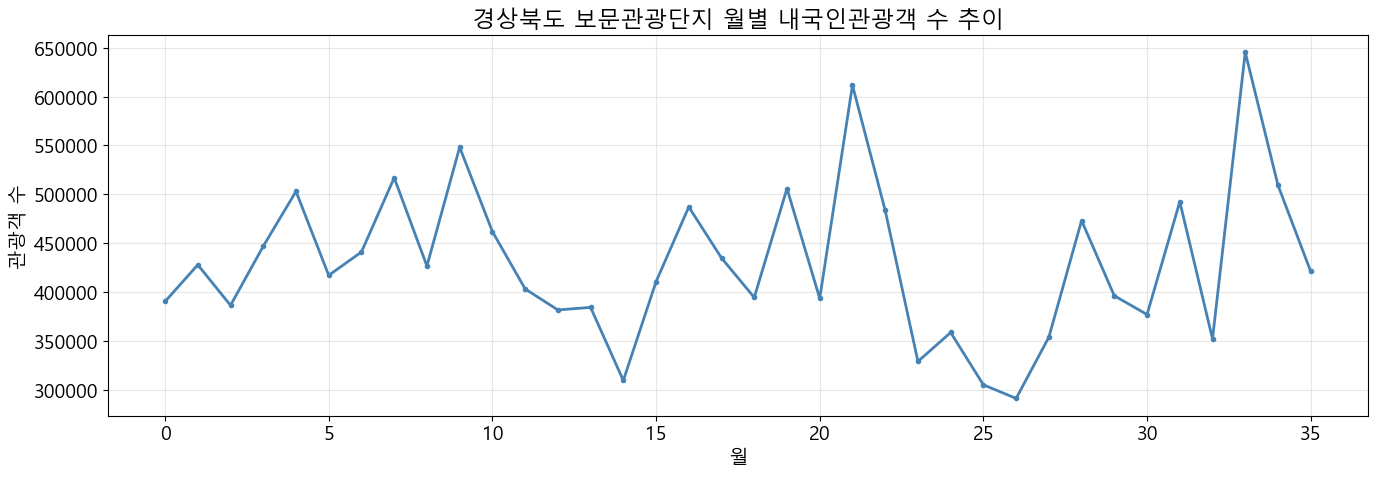

내국인관광객수 통계:
count        36.0000
mean    429,641.7222
std      80,096.8275
min     290,892.0000
25%     383,496.2500
50%     418,959.5000
75%     484,371.5000
max     645,515.0000
Name: 내국인관광객수, dtype: float64


In [3]:
# 월별 내국인관광객수 추이 시각화
plt.figure(figsize=(14, 5))
plt.plot(range(len(df)), df['내국인관광객수'], linewidth=2, color='steelblue', marker='o', markersize=3)
plt.title('경상북도 보문관광단지 월별 내국인관광객 수 추이')
plt.xlabel('월')
plt.ylabel('관광객 수')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# 데이터 통계
print('내국인관광객수 통계:')
print(df['내국인관광객수'].describe())

## 3단계: 데이터 준비 (피처/타겟 설정 및 분할)

In [4]:
# 피처와 타겟 설정
# 입력: 국적별 외국인 관광객 수
# 출력: 내국인관광객수

feature_cols = ['외국인관광객수', '중국국적관광객수', '대만국적관광객수', 
                '홍콩국적관광객수', '일본국적관광객수', '미국국적관광객수', 
                '유럽국적관광객수', '기타국적관광객수']
X = df[feature_cols]
y = df['내국인관광객수']

# 시간 순서 유지 - 앞 80%를 학습, 뒤 20%를 테스트
split_idx = int(len(df) * 0.8)
X_train = X.iloc[:split_idx]
X_test = X.iloc[split_idx:]
y_train = y.iloc[:split_idx]
y_test = y.iloc[split_idx:]

print(f'전체 데이터: {len(df)}행')
print(f'학습 데이터: {len(X_train)}행 ({df["기준연월일"].iloc[0]} ~ {df["기준연월일"].iloc[split_idx-1]})')
print(f'테스트 데이터: {len(X_test)}행 ({df["기준연월일"].iloc[split_idx]} ~ {df["기준연월일"].iloc[-1]})')
print()
print('Y(내국인관광객수) 통계:')
print(f'학습 데이터: 평균={y_train.mean():.0f}, 최소={y_train.min():.0f}, 최대={y_train.max():.0f}')
print(f'테스트 데이터: 평균={y_test.mean():.0f}, 최소={y_test.min():.0f}, 최대={y_test.max():.0f}')

전체 데이터: 36행
학습 데이터: 28행 (2023-01-01 ~ 2025-04-01)
테스트 데이터: 8행 (2025-05-01 ~ 2025-12-01)

Y(내국인관광객수) 통계:
학습 데이터: 평균=421469, 최소=290892, 최대=611820
테스트 데이터: 평균=458246, 최소=351879, 최대=645515


## 4단계: 모델 학습 (의사결정나무 회귀)

In [5]:
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import math

# 의사결정나무 회귀 모델 학습
dt_model = DecisionTreeRegressor(max_depth=5, random_state=random_seed)
dt_model.fit(X_train, y_train)

# 예측
y_pred = dt_model.predict(X_test)

print('모델 학습 완료!')
print(f'모델 파라미터: max_depth=5, random_state={random_seed}')

모델 학습 완료!
모델 파라미터: max_depth=5, random_state=123


## 5단계: 예측 및 평가

In [6]:
# 평가 지표 계산
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = math.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print('=== 의사결정나무 회귀 결과 ===')
print(f'평균절대오차(MAE):  {mae:,.0f}')
print(f'평균제곱오차(MSE):  {mse:,.0f}')
print(f'루트평균제곱오차(RMSE): {rmse:,.0f}')
print(f'결정계수(R²):      {r2:.4f}')
print()
print('테스트 데이터의 실제값 vs 예측값:')
result_df = pd.DataFrame({
    '기준연월일': df['기준연월일'].iloc[split_idx:].values,
    '실제값': y_test.values,
    '예측값': y_pred.astype(int),
    '오차': (y_test.values - y_pred).astype(int),
    '오차율': ((y_test.values - y_pred) / y_test.values * 100).round(2)
})
print(result_df.to_string(index=False))

=== 의사결정나무 회귀 결과 ===
평균절대오차(MAE):  78,031
평균제곱오차(MSE):  8,190,187,896
루트평균제곱오차(RMSE): 90,500
결정계수(R²):      -0.0523

테스트 데이터의 실제값 vs 예측값:
     기준연월일    실제값    예측값      오차      오차율
2025-05-01 473131 353603  119528  25.2600
2025-06-01 396032 391523    4508   1.1400
2025-07-01 376839 511448 -134609 -35.7200
2025-08-01 492373 446814   45559   9.2500
2025-09-01 351879 485256 -133377 -37.9000
2025-10-01 645515 611820   33695   5.2200
2025-11-01 509267 446814   62453  12.2600
2025-12-01 420928 511448  -90520 -21.5000


## 6단계: 결과 분석 및 시각화

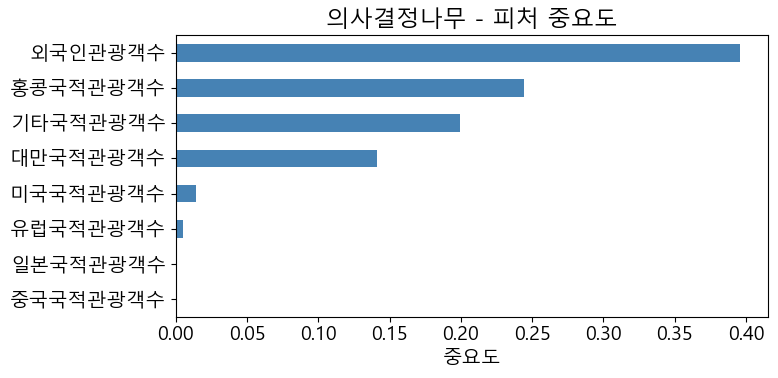

In [7]:
# 피처 중요도 시각화
importance = pd.Series(dt_model.feature_importances_, index=feature_cols)
importance.sort_values(ascending=True).plot(kind='barh', figsize=(8, 4), color='steelblue')
plt.title('의사결정나무 - 피처 중요도')
plt.xlabel('중요도')
plt.tight_layout()
plt.show()

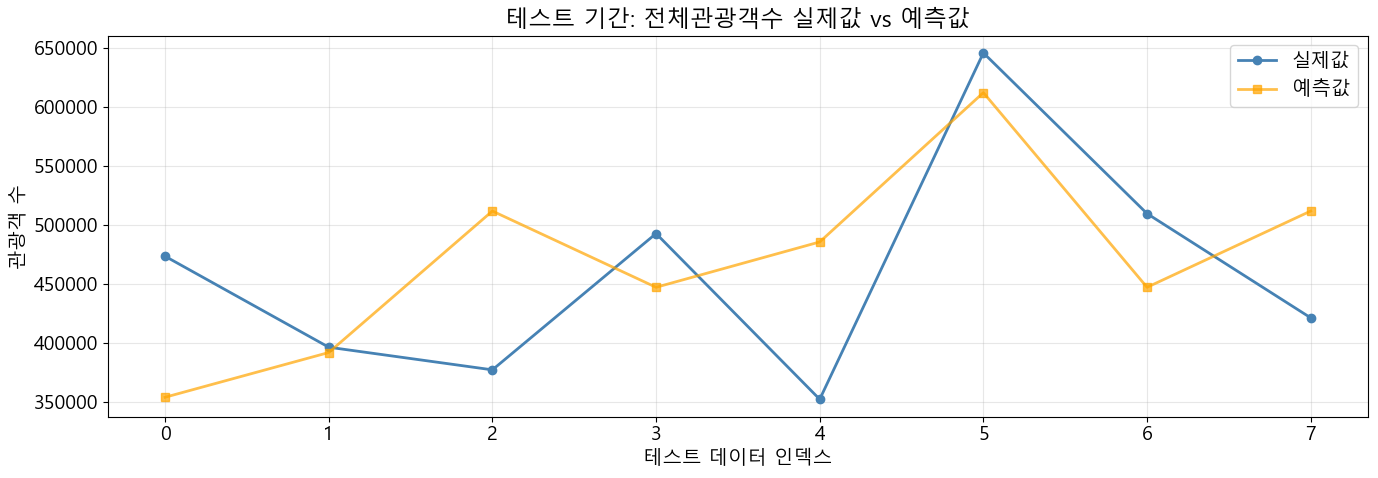

In [8]:
# 예측 vs 실제 비교 시각화
plt.figure(figsize=(14, 5))
x_pos = range(len(y_test))
plt.plot(x_pos, y_test.values, label='실제값', marker='o', linewidth=2, markersize=6, color='steelblue')
plt.plot(x_pos, y_pred, label='예측값', marker='s', linewidth=2, markersize=6, color='orange', alpha=0.7)
plt.title('테스트 기간: 전체관광객수 실제값 vs 예측값')
plt.xlabel('테스트 데이터 인덱스')
plt.ylabel('관광객 수')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

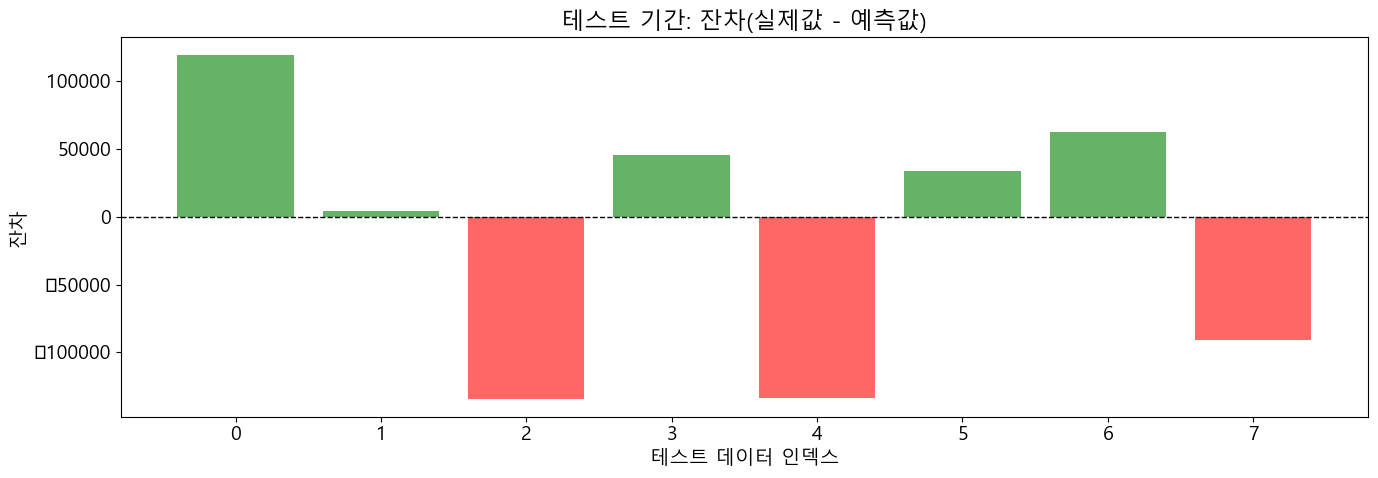

In [9]:
# 잔차(오차) 시각화
residuals = y_test.values - y_pred
plt.figure(figsize=(14, 5))
plt.bar(range(len(residuals)), residuals, color=['green' if r > 0 else 'red' for r in residuals], alpha=0.6)
plt.axhline(y=0, color='black', linestyle='--', linewidth=1)
plt.title('테스트 기간: 잔차(실제값 - 예측값)')
plt.xlabel('테스트 데이터 인덱스')
plt.ylabel('잔차')
plt.tight_layout()
plt.show()